<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Intel_4004_Layout_and_3D_STL_Model_Output_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
!uv pip install phidl gdstk matplotlib requests numpy

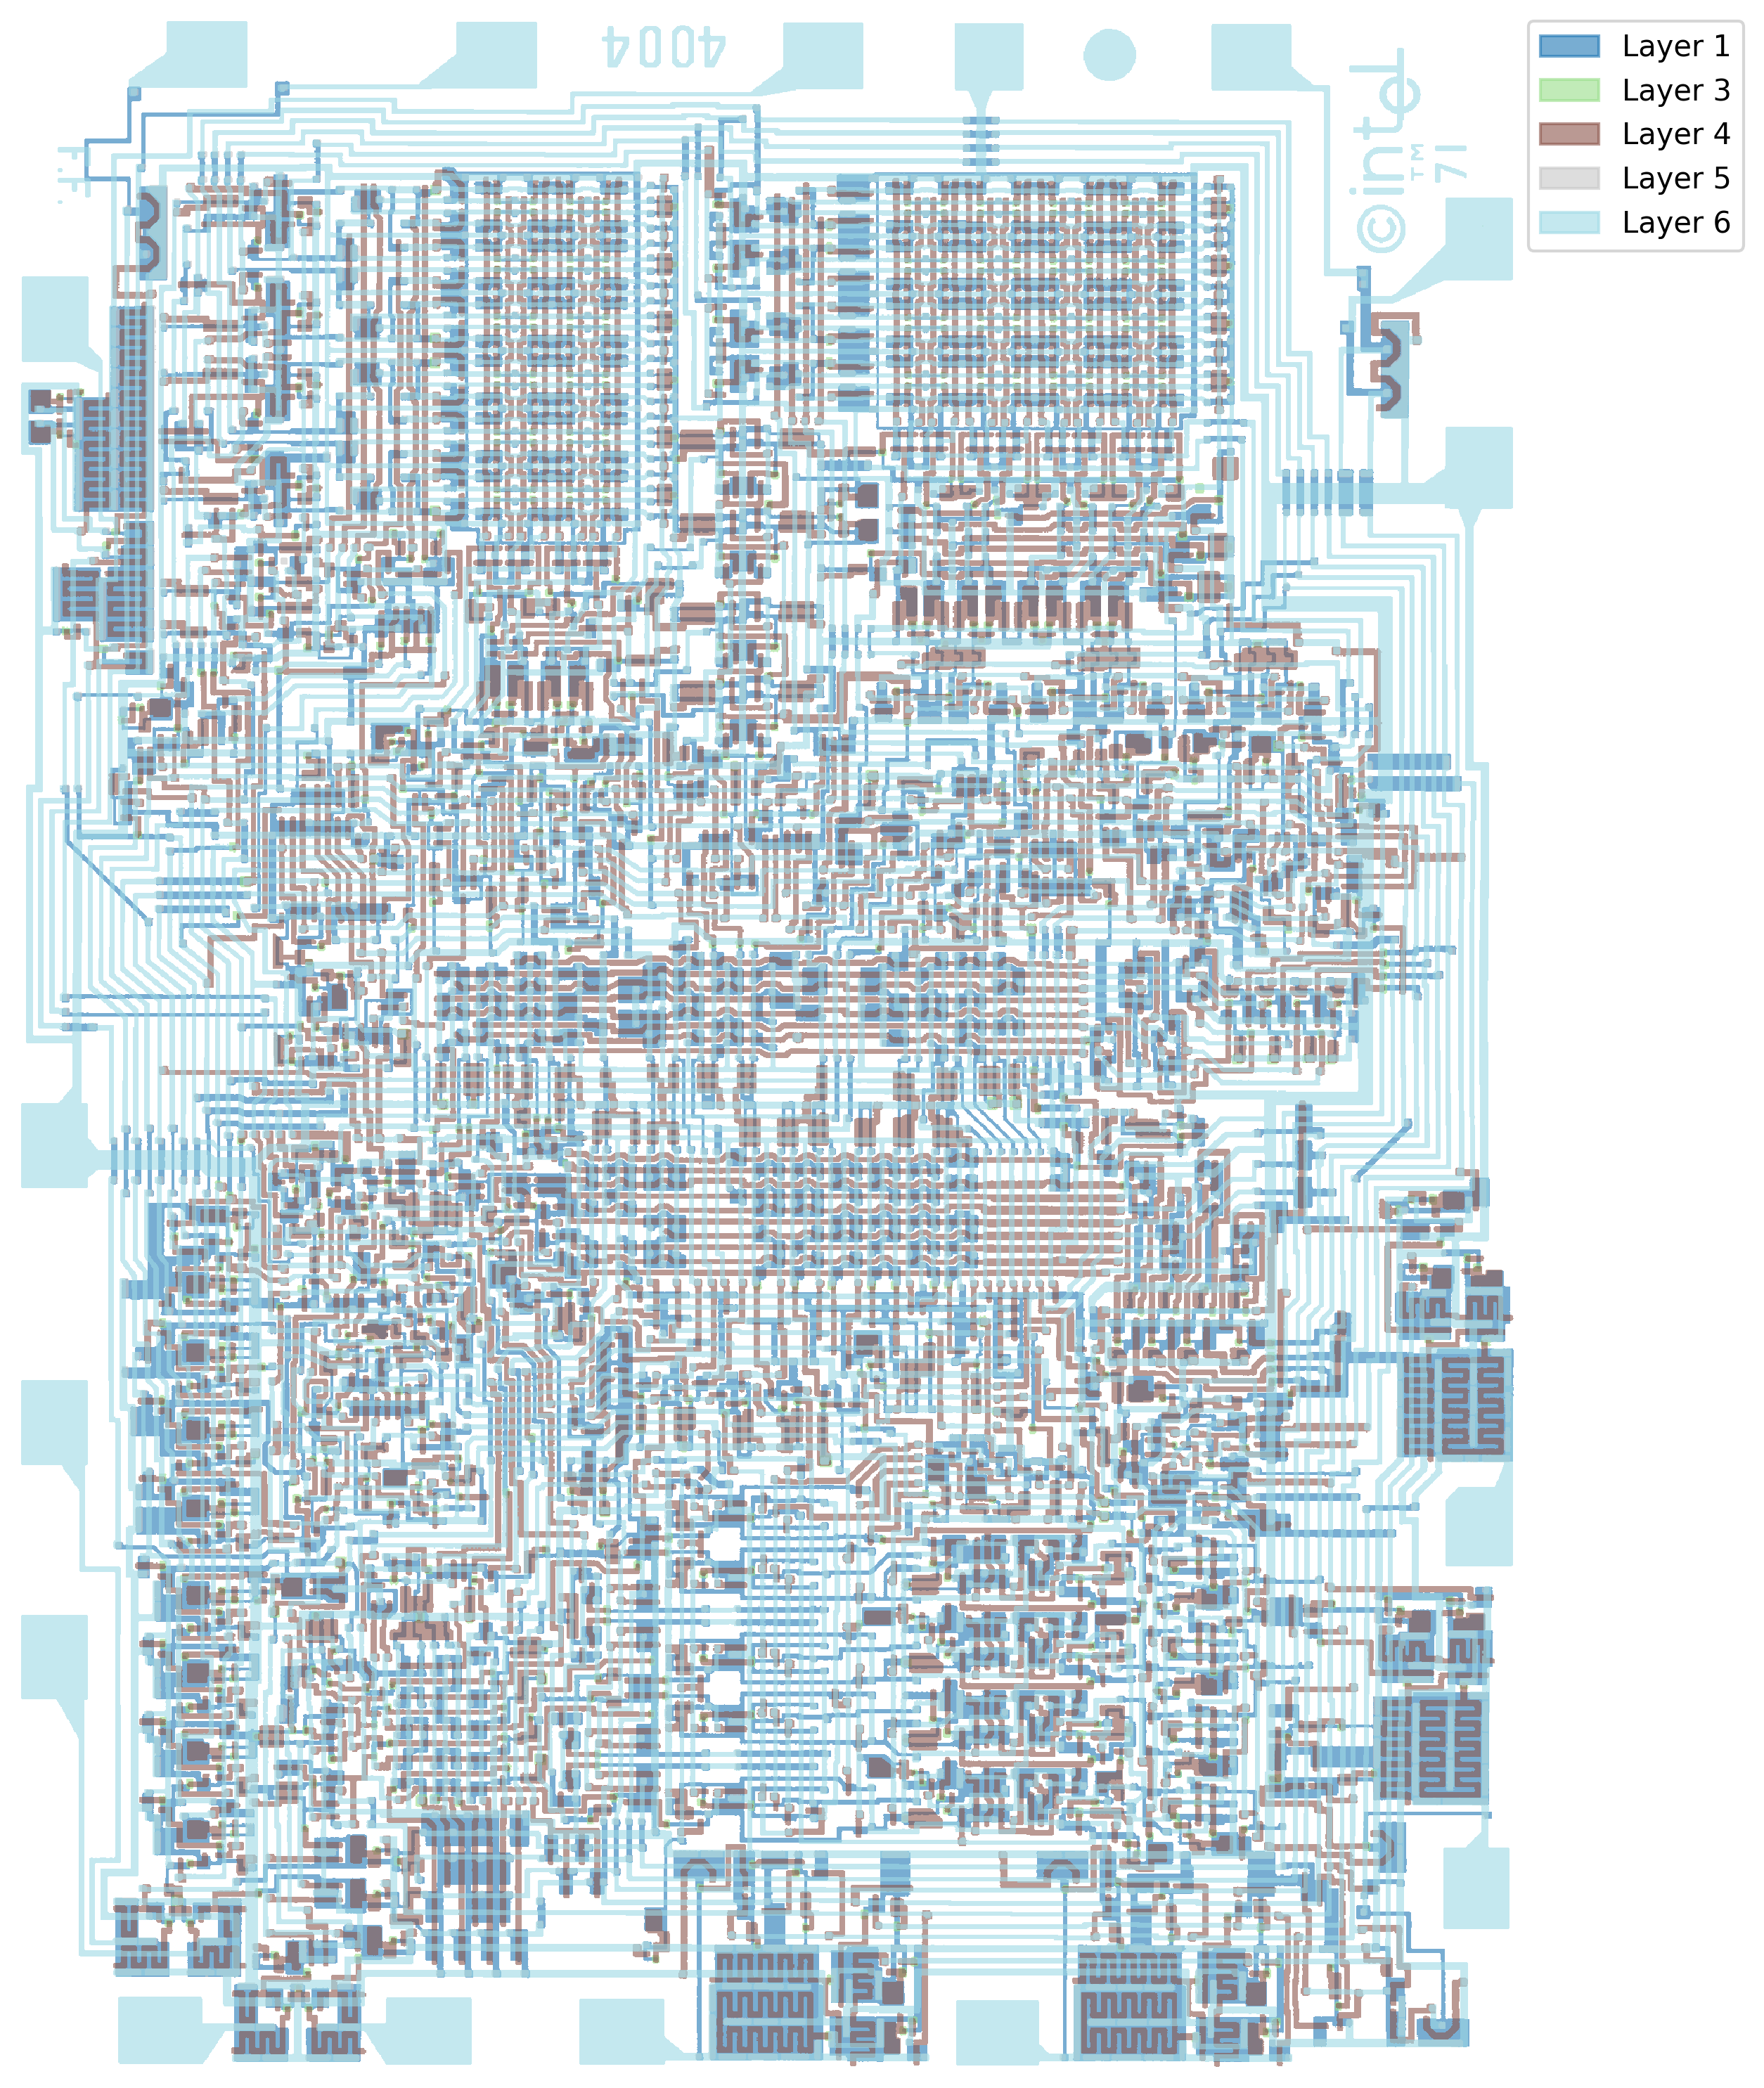

In [4]:
"""This script downloads, processes, classifies, and visualizes the Intel 4004 layout."""

import urllib.request

import gdstk
import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import PolyCollection
from phidl import Device
import phidl.geometry as pg

# Control Knobs
SOURCE_URL: str = "https://raw.githubusercontent.com/purdue-onchip/gds2Para/master/examples/4004.gds"
DOWNLOADED_FILENAME: str = "4004_original.gds"
OUTPUT_FILENAME: str = "Intel_4004.gds"
RENDER_DPI: int = 300
FIGURE_SIZE: tuple[float, float] = (14.0, 10.0)
PLOT_ALPHA: float = 0.6
COLOR_MAP_NAME: str = "tab20"

def main() -> None:
    """Executes the geometric extraction, layer specific mapping, and rendering procedures.

    Returns:
        None
    """
    # Enforce typography and resolution settings
    matplotlib.rcParams.update({
        'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
        'font.weight': 'normal',
        'figure.dpi': RENDER_DPI,
    })

    # Retrieve the layout file from the remote repository
    urllib.request.urlretrieve(SOURCE_URL, DOWNLOADED_FILENAME)

    # Utilize Graphic Design System II Tool Kit (GDSTK) for robust parsing
    library = gdstk.read_gds(DOWNLOADED_FILENAME)
    top_cells = library.top_level()
    main_cell = top_cells[0]

    # Programmatically define an enclosure using PHIDL to establish integration
    bbox = main_cell.bounding_box()
    phidl_enclosure = pg.bbox([bbox[0], bbox[1]])
    auxiliary_device = Device("Enclosure")
    auxiliary_device.add_ref(phidl_enclosure)

    # Output the parsed geometry to a new file
    library.write_gds(OUTPUT_FILENAME)

    # Extract polygons while ensuring all hierarchical structures resolve dynamically
    raw_polygons = main_cell.get_polygons(True)

    # Categorize numerical vertex arrays according to their designated semiconductor layer
    layer_to_vertices: dict[int, list[np.ndarray]] = {}
    for poly in raw_polygons:
        layer: int = poly.layer
        if layer not in layer_to_vertices:
            layer_to_vertices[layer] = []
        layer_to_vertices[layer].append(poly.points)

    # Initialize the rendering canvas with expanded horizontal dimensions
    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    # Configure color distribution mechanics
    unique_layers: list[int] = sorted(list(layer_to_vertices.keys()))
    colormap = plt.get_cmap(COLOR_MAP_NAME)
    color_count: int = len(unique_layers)
    legend_patches: list[mpatches.Patch] = []

    # Iterate sequentially through the sorted layers to populate the visual collections
    for index, layer in enumerate(unique_layers):
        # Calculate a normalized chromatic index
        color = colormap(float(index) / max(1, color_count - 1))
        polygon_vertices = layer_to_vertices[layer]

        # Deploy a PolyCollection to handle the polygon density efficiently
        collection = PolyCollection(
            polygon_vertices,
            facecolors=[color],
            edgecolors='none',
            alpha=PLOT_ALPHA
        )
        ax.add_collection(collection)

        # Construct a discrete patch object to populate the external legend
        patch = mpatches.Patch(
            color=color,
            label=f"Layer {layer}",
            alpha=PLOT_ALPHA
        )
        legend_patches.append(patch)

    # Configure spatial dimensions and visual framing based on the exact bounding box
    ax.set_xlim(bbox[0][0], bbox[1][0])
    ax.set_ylim(bbox[0][1], bbox[1][1])
    ax.set_aspect('equal')
    ax.axis('off')

    ax.legend(
        handles=legend_patches,
        bbox_to_anchor=(1.01, 1),
        loc='upper left',
        borderaxespad=0.0
    )

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [3]:
"""Convert selected GDSII layers into an STL model with gds2stl.

The script clones the upstream converter, installs its declared dependencies,
downloads the source GDSII file, writes the JSON configuration hierarchy
required by the converter, applies compatibility patches, and runs the
conversion in the active Python environment.
"""

from collections import deque
import json
import math
import os
from pathlib import Path
import re
import shutil
import subprocess
import sys
import tempfile
from typing import Final, Iterable, Mapping, Sequence
from urllib.error import HTTPError, URLError
from urllib.request import Request, urlopen


# Control knobs
REPOSITORY_URL: Final[str] = "https://github.com/janikwitzig/gds2stl.git"
REPOSITORY_DIRECTORY: Final[Path] = Path("gds2stl")
SOURCE_URL: Final[str] = (
    "https://raw.githubusercontent.com/purdue-onchip/gds2Para/"
    "master/examples/4004.gds"
)
DOWNLOADED_GDS_PATH: Final[Path] = Path("4004_original.gds")
OUTPUT_STL_PATH: Final[Path] = Path("4004_3d_model.stl")
CONFIG_ROOT: Final[Path] = Path("gds2stl_runtime_config")
TECHNOLOGY_DIRECTORY: Final[Path] = CONFIG_ROOT / "technology"
USER_CONFIG_PATH: Final[Path] = CONFIG_ROOT / "user.json"

FORCE_RECLONE: Final[bool] = False
FORCE_REDOWNLOAD: Final[bool] = False
OVERWRITE_OUTPUT: Final[bool] = True
INSTALL_DEPENDENCIES: Final[bool] = True
USE_UV: Final[bool] = True
DISABLE_INTERACTIVE_VIEWER: Final[bool] = True
CUT_RECTANGLE: Final[tuple[float, float, float, float] | None] = None
DOWNLOAD_TIMEOUT_SECONDS: Final[int] = 180
SUBPROCESS_LOG_HISTORY: Final[int] = 200
Z_TOLERANCE: Final[float] = 1.0e-9

# Each entry is GDS layer: (base elevation, extrusion thickness), in micrometers.
LAYER_MAPPING: Final[dict[int, tuple[float, float]]] = {
    1: (0.0, 1.5),
    2: (1.5, 0.8),
    3: (2.3, 1.2),
    4: (3.5, 1.0),
    5: (4.5, 2.0),
    6: (6.5, 1.0),
}


class CommandExecutionError(RuntimeError):
    """Indicates that an external command returned a nonzero status."""


def run_command(
    command: Sequence[str],
    *,
    cwd: Path | None = None,
    environment: Mapping[str, str] | None = None,
) -> None:
    """Run a command, stream its output, and preserve recent diagnostic lines.

    Args:
        command: Command and arguments to execute.
        cwd: Optional working directory.
        environment: Optional environment mapping.

    Raises:
        CommandExecutionError: The command exits with a nonzero status.
    """
    printable_command = " ".join(str(part) for part in command)
    print(f"\n$ {printable_command}")

    process = subprocess.Popen(
        [str(part) for part in command],
        cwd=str(cwd) if cwd is not None else None,
        env=dict(environment) if environment is not None else None,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    recent_output: deque[str] = deque(maxlen=SUBPROCESS_LOG_HISTORY)
    if process.stdout is None:
        process.kill()
        raise CommandExecutionError("The subprocess output stream was unavailable.")

    for line in process.stdout:
        print(line, end="")
        recent_output.append(line.rstrip())

    return_code = process.wait()
    if return_code == 0:
        return

    diagnostic_tail = "\n".join(recent_output)
    raise CommandExecutionError(
        f"Command exited with status {return_code}: {printable_command}\n"
        f"Recent output:\n{diagnostic_tail}"
    )


def prepare_repository(repository_path: Path) -> None:
    """Clone the converter repository or validate an existing checkout.

    Args:
        repository_path: Local repository directory.

    Raises:
        RuntimeError: An existing path lacks the required repository files.
    """
    if FORCE_RECLONE and repository_path.exists():
        shutil.rmtree(repository_path)

    if repository_path.exists():
        required_paths = (
            repository_path / "main.py",
            repository_path / "requirements.txt",
            repository_path / "geometry2d" / "shape.py",
        )
        missing_paths = [path for path in required_paths if path.exists() is False]
        if missing_paths:
            formatted = ", ".join(str(path) for path in missing_paths)
            raise RuntimeError(
                f"The existing repository directory is incomplete: {formatted}. "
                "Set FORCE_RECLONE to True and run the script again."
            )
        print(f"Using existing repository: {repository_path.resolve()}")
        return

    run_command(
        [
            "git",
            "clone",
            "--depth",
            "1",
            REPOSITORY_URL,
            str(repository_path),
        ]
    )


def ensure_uv_available() -> str:
    """Return the uv executable path, installing uv if required.

    Returns:
        Path-like executable name accepted by subprocess.
    """
    uv_path = shutil.which("uv")
    if uv_path is not None:
        return uv_path

    run_command([sys.executable, "-m", "pip", "install", "uv"])
    uv_path = shutil.which("uv")
    if uv_path is None:
        raise RuntimeError("uv installation completed without an executable on PATH.")
    return uv_path


def install_repository_dependencies(repository_path: Path) -> None:
    """Install the dependencies declared by the upstream repository.

    Args:
        repository_path: Local repository directory.
    """
    if INSTALL_DEPENDENCIES is False:
        return

    requirements_path = (repository_path / "requirements.txt").resolve()
    if USE_UV:
        uv_executable = ensure_uv_available()
        command = [
            uv_executable,
            "pip",
            "install",
            "--python",
            sys.executable,
        ]
        if sys.prefix == sys.base_prefix:
            command.append("--system")
        command.extend(["-r", str(requirements_path)])
        try:
            run_command(command)
            return
        except CommandExecutionError as error:
            print(f"uv dependency installation failed. Falling back to pip.\n{error}")

    run_command(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            str(requirements_path),
        ]
    )


def download_file(url: str, destination: Path) -> None:
    """Download a remote file atomically.

    Args:
        url: Remote file URL.
        destination: Local output path.

    Raises:
        RuntimeError: The transfer fails or produces an empty file.
    """
    if (
        destination.exists()
        and destination.stat().st_size > 0
        and FORCE_REDOWNLOAD is False
    ):
        print(f"Using existing GDSII file: {destination.resolve()}")
        return

    destination.parent.mkdir(parents=True, exist_ok=True)
    request = Request(url, headers={"User-Agent": "gds2stl-conversion-script/1.0"})
    temporary_path: Path | None = None

    try:
        with urlopen(request, timeout=DOWNLOAD_TIMEOUT_SECONDS) as response:
            with tempfile.NamedTemporaryFile(
                mode="wb",
                delete=False,
                dir=destination.parent,
                prefix=f".{destination.name}.",
            ) as temporary_file:
                temporary_path = Path(temporary_file.name)
                shutil.copyfileobj(response, temporary_file)

        if temporary_path.stat().st_size == 0:
            raise RuntimeError(f"The downloaded file is empty: {url}")
        temporary_path.replace(destination)
    except (HTTPError, URLError, TimeoutError, OSError) as error:
        if temporary_path is not None and temporary_path.exists():
            temporary_path.unlink()
        raise RuntimeError(f"Unable to download {url}: {error}") from error

    print(
        f"Downloaded {destination.resolve()} "
        f"({destination.stat().st_size / (1024 ** 2):.2f} MiB)"
    )


def detect_gds_layer_datatypes(gds_path: Path) -> dict[int, set[int]]:
    """Read the GDSII library and collect layer and datatype combinations.

    Args:
        gds_path: Input GDSII path.

    Returns:
        Mapping from each detected GDS layer to its datatypes.

    Raises:
        RuntimeError: The GDSII file contains no polygonal layout layers.
    """
    import gdstk  # pylint: disable=import-outside-toplevel

    library = gdstk.read_gds(str(gds_path))
    layer_datatypes: dict[int, set[int]] = {}

    for cell in library.cells:
        for polygon in cell.polygons:
            layer_datatypes.setdefault(int(polygon.layer), set()).add(
                int(polygon.datatype)
            )
        for path in cell.paths:
            for layer, datatype in zip(path.layers, path.datatypes):
                layer_datatypes.setdefault(int(layer), set()).add(int(datatype))

    if layer_datatypes:
        return layer_datatypes
    raise RuntimeError("The GDSII file contains no polygons or paths.")


def format_detected_layers(layer_datatypes: Mapping[int, Iterable[int]]) -> str:
    """Format layer and datatype combinations for terminal output.

    Args:
        layer_datatypes: Detected GDS layer mapping.

    Returns:
        Compact human-readable layer description.
    """
    entries = []
    for layer in sorted(layer_datatypes):
        datatypes = ",".join(str(value) for value in sorted(layer_datatypes[layer]))
        entries.append(f"{layer}:[{datatypes}]")
    return " ".join(entries)


def validate_layer_mapping(
    layer_mapping: Mapping[int, tuple[float, float]],
) -> list[tuple[int, float, float]]:
    """Validate and sort the configured physical layer stack.

    Args:
        layer_mapping: Mapping from GDS layer to elevation and thickness.

    Returns:
        Entries sorted by elevation and GDS layer.

    Raises:
        ValueError: Values are nonfinite, nonpositive, or overlap in z.
    """
    sorted_entries = sorted(
        (
            (int(layer), float(values[0]), float(values[1]))
            for layer, values in layer_mapping.items()
        ),
        key=lambda entry: (entry[1], entry[0]),
    )
    if len(sorted_entries) == 0:
        raise ValueError("LAYER_MAPPING must contain at least one layer.")

    previous_top: float | None = None
    for layer, elevation, thickness in sorted_entries:
        if math.isfinite(elevation) is False or math.isfinite(thickness) is False:
            raise ValueError(f"Layer {layer} contains a nonfinite stack value.")
        if thickness <= 0.0:
            raise ValueError(f"Layer {layer} must have positive thickness.")
        if previous_top is not None and elevation < previous_top - Z_TOLERANCE:
            raise ValueError(
                f"Layer {layer} starts at z={elevation}, below the preceding "
                f"stack top z={previous_top}. The upstream z resolver cannot "
                "represent overlapping configured layers."
            )
        previous_top = elevation + thickness

    return sorted_entries


def write_json(path: Path, payload: object) -> None:
    """Write a deterministic UTF-8 JSON file.

    Args:
        path: Destination path.
        payload: JSON-serializable object.
    """
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as output_file:
        json.dump(payload, output_file, indent=2)
        output_file.write("\n")


def build_configuration_files(
    layer_datatypes: Mapping[int, set[int]],
) -> tuple[Path, Path]:
    """Create the technology directory and separate user configuration file.

    Args:
        layer_datatypes: Detected GDS layer and datatype combinations.

    Returns:
        Technology directory and user configuration paths.

    Raises:
        RuntimeError: The configured stack matches no layers in the GDSII file.
    """
    stack_entries = validate_layer_mapping(LAYER_MAPPING)
    configured_layer_numbers = {entry[0] for entry in stack_entries}
    matched_layers = configured_layer_numbers.intersection(layer_datatypes)
    if len(matched_layers) == 0:
        detected = format_detected_layers(layer_datatypes)
        raise RuntimeError(
            "None of the GDS layers in LAYER_MAPPING occur in the input file. "
            f"Detected layers and datatypes: {detected}"
        )

    omitted_layers = sorted(set(layer_datatypes).difference(configured_layer_numbers))
    if omitted_layers:
        print(
            "Detected GDS layers omitted by LAYER_MAPPING: "
            + ", ".join(str(layer) for layer in omitted_layers)
        )

    layers_config: dict[str, dict[str, int | list[int]]] = {}
    user_layers: dict[str, dict[str, float]] = {}
    first_elevation = stack_entries[0][1]
    current_z = first_elevation
    spacer_index = 0

    for layer, elevation, thickness in stack_entries:
        gap = elevation - current_z
        if gap > Z_TOLERANCE:
            spacer_name = f"__z_gap_{spacer_index:03d}"
            layers_config[spacer_name] = {
                "layer": -(spacer_index + 1),
                "datatype": 0,
            }
            user_layers[spacer_name] = {"height": gap}
            spacer_index += 1
            current_z = elevation

        datatypes = sorted(layer_datatypes.get(layer, {0}))
        datatype_value: int | list[int]
        if len(datatypes) == 1:
            datatype_value = datatypes[0]
        else:
            datatype_value = datatypes

        layer_name = f"layer_{layer}"
        layers_config[layer_name] = {
            "layer": layer,
            "datatype": datatype_value,
        }
        user_layers[layer_name] = {"height": thickness}
        current_z = elevation + thickness

    technology_rules = {
        "subtract": {},
        "extend_down_to": {},
    }
    user_config = {
        "default_z_start": first_elevation,
        "layers": user_layers,
    }

    layers_path = TECHNOLOGY_DIRECTORY / "layers.json"
    technology_rules_path = TECHNOLOGY_DIRECTORY / "tech.json"
    write_json(layers_path, layers_config)
    write_json(technology_rules_path, technology_rules)
    write_json(USER_CONFIG_PATH, user_config)

    return TECHNOLOGY_DIRECTORY.resolve(), USER_CONFIG_PATH.resolve()


def prepend_future_annotations(source_path: Path) -> None:
    """Enable deferred annotation evaluation in a repository source module.

    Args:
        source_path: Python source file to patch.
    """
    source = source_path.read_text(encoding="utf-8")
    future_import = "from __future__ import annotations"
    if future_import in source:
        return
    source_path.write_text(
        f"{future_import}\n\n{source}",
        encoding="utf-8",
    )


def patch_solid_initialization(source_path: Path) -> None:
    """Initialize the solid name before the first geometry build.

    Args:
        source_path: Upstream Solid3D source file.
    """
    source = source_path.read_text(encoding="utf-8")
    original = (
        "        self.shape2d = shape2d\n"
        "        self.height = height\n"
        "        self.mesh = self.build()\n"
        "        self.name = name or \"Solid3D\"\n"
    )
    replacement = (
        "        self.shape2d = shape2d\n"
        "        self.height = height\n"
        "        self.name = name or \"Solid3D\"\n"
        "        self.mesh = self.build()\n"
    )
    if original in source:
        source_path.write_text(source.replace(original, replacement), encoding="utf-8")


def patch_simple_type_aliases(repository_path: Path) -> None:
    """Translate simple Python 3.12 type aliases for older interpreters.

    Args:
        repository_path: Local repository directory.
    """
    type_alias_pattern = re.compile(
        r"^(?P<indent>\s*)type\s+(?P<name>[A-Za-z_]\w*)\s*=\s*",
        flags=re.MULTILINE,
    )
    for source_path in repository_path.rglob("*.py"):
        source = source_path.read_text(encoding="utf-8")
        patched = type_alias_pattern.sub(
            r"\g<indent>\g<name> = ",
            source,
        )
        if patched != source:
            source_path.write_text(patched, encoding="utf-8")


def validate_repository_sources(repository_path: Path) -> None:
    """Compile and import the patched upstream entry module.

    Args:
        repository_path: Local repository directory.
    """
    run_command(
        [sys.executable, "-m", "compileall", "-q", str(repository_path)]
    )
    environment = os.environ.copy()
    environment["MPLBACKEND"] = "Agg"
    run_command(
        [sys.executable, "-c", "import main"],
        cwd=repository_path,
        environment=environment,
    )


def patch_repository_sources(repository_path: Path) -> None:
    """Apply compatibility corrections required by the upstream source.

    Args:
        repository_path: Local repository directory.
    """
    patch_simple_type_aliases(repository_path)
    prepend_future_annotations(repository_path / "geometry2d" / "shape.py")
    patch_solid_initialization(repository_path / "geometry3d" / "solid.py")


def find_converter_entry_point(repository_path: Path) -> Path:
    """Locate the converter's executable Python module.

    Args:
        repository_path: Local repository directory.

    Returns:
        Existing entry-point path.

    Raises:
        FileNotFoundError: No supported entry point exists.
    """
    candidates = (
        repository_path / "main.py",
        repository_path / "gds2stl.py",
    )
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No converter entry point was found in {repository_path.resolve()}."
    )


def run_conversion(
    entry_point: Path,
    gds_path: Path,
    technology_directory: Path,
    user_config_path: Path,
    output_path: Path,
) -> None:
    """Execute the upstream converter with its required configuration paths.

    Args:
        entry_point: Upstream main module.
        gds_path: Input GDSII file.
        technology_directory: Directory containing layers.json and tech.json.
        user_config_path: Separate user display and height configuration.
        output_path: STL output path.
    """
    if output_path.exists():
        if OVERWRITE_OUTPUT:
            output_path.unlink()
        else:
            raise FileExistsError(
                f"Output already exists and OVERWRITE_OUTPUT is False: {output_path}"
            )

    output_path.parent.mkdir(parents=True, exist_ok=True)
    command = [
        sys.executable,
        str(entry_point),
        str(gds_path.resolve()),
        "--tech",
        str(technology_directory),
        "--config",
        str(user_config_path),
    ]
    if CUT_RECTANGLE is not None:
        xmin, ymin, xmax, ymax = CUT_RECTANGLE
        if xmin >= xmax or ymin >= ymax:
            raise ValueError(
                "CUT_RECTANGLE must satisfy xmin < xmax and ymin < ymax."
            )
        command.extend(
            ["--cut", str(xmin), str(ymin), str(xmax), str(ymax)]
        )
    command.extend(["-o", str(output_path.resolve())])
    if DISABLE_INTERACTIVE_VIEWER:
        command.append("--no-show")

    environment = os.environ.copy()
    environment["MPLBACKEND"] = "Agg"
    environment["PYTHONUNBUFFERED"] = "1"
    run_command(command, environment=environment)

    if output_path.is_file() is False or output_path.stat().st_size == 0:
        raise RuntimeError(
            "The converter exited successfully without producing a nonempty STL file."
        )


def main() -> None:
    """Prepare the converter, generate its configs, and create the STL model."""
    repository_path = REPOSITORY_DIRECTORY.resolve()
    gds_path = DOWNLOADED_GDS_PATH.resolve()
    output_path = OUTPUT_STL_PATH.resolve()

    prepare_repository(repository_path)
    install_repository_dependencies(repository_path)
    patch_repository_sources(repository_path)
    validate_repository_sources(repository_path)
    download_file(SOURCE_URL, gds_path)

    detected_layers = detect_gds_layer_datatypes(gds_path)
    print(
        "Detected GDS layers and datatypes: "
        f"{format_detected_layers(detected_layers)}"
    )
    technology_directory, user_config_path = build_configuration_files(
        detected_layers
    )

    entry_point = find_converter_entry_point(repository_path)
    run_conversion(
        entry_point,
        gds_path,
        technology_directory,
        user_config_path,
        output_path,
    )

    print(f"\nSTL conversion completed: {output_path}")
    print(f"Output size: {output_path.stat().st_size / (1024 ** 2):.2f} MiB")
    print(f"Technology directory: {technology_directory}")
    print(f"User configuration: {user_config_path}")


if __name__ == "__main__":
    main()


$ git clone --depth 1 https://github.com/janikwitzig/gds2stl.git /content/gds2stl
Cloning into '/content/gds2stl'...

$ /usr/local/bin/uv pip install --python /usr/bin/python3 --system -r /content/gds2stl/requirements.txt
Using Python 3.12.13 environment at: /usr
Resolved 21 packages in 209ms
Prepared 3 packages in 101ms
Installed 3 packages in 9ms
 + mapbox-earcut==2.0.0
 + pyglet==1.5.31
 + trimesh==4.12.2

$ /usr/bin/python3 -m compileall -q /content/gds2stl

$ /usr/bin/python3 -c import main
Using existing GDSII file: /content/4004_original.gds
Detected GDS layers and datatypes: 1:[0] 3:[0] 4:[0] 5:[0] 6:[0]

$ /usr/bin/python3 /content/gds2stl/main.py /content/4004_original.gds --tech /content/gds2stl_runtime_config/technology --config /content/gds2stl_runtime_config/user.json -o /content/4004_3d_model.stl --no-show
──────────────────────────────── Running GDS23D ────────────────────────────────
Loaded GDS file /content/4004_original.gds
Cell flattened
                    1917.00